# Membuat algoritma shor 

***1. Mengimport Library yang di butuhkan***

In [7]:
import numpy as np
import math
import random
from fractions import Fraction

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

from qiskit.circuit.library import UnitaryGate
from qiskit.circuit.library import UnitaryGate
from qiskit import QuantumCircuit, transpile
from qiskit.circuit.library import QFT
from qiskit.quantum_info import Operator
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram

import matplotlib.pyplot as plt

***2. Membuat fungsi untuk mendapatkan nilai a yang paling optimal***

In [8]:
def get_coprime_candidates(N):
    """
    Hanya filter syarat matematika dasar:
    1. 1 < a < N-1
    2. gcd(a, N) = 1
    Tidak ada pengecekan r, tidak ada pengecekan trivial!
    """
    coprimes = [a for a in range(2, N-1) if math.gcd(a, N) == 1]
    random.shuffle(coprimes)
    return coprimes

***3. Menginput nilai N untuk N adalah bilangan komposit, dengan mengetahui jumlah qubit dan phase register dengan work registernya***

In [9]:
N = 35

# Cari a otomatis
a = random.choice(get_coprime_candidates(N))

# Lanjut seperti biasa
n = math.ceil(math.log2(N))
n_count = 2 * n

print(f"\nMenjalankan Shor dengan N={N}, a={a}")
print(f"phase register = {n_count}, work register = {n}")
print(f"Total qubits = {n_count + n}\n")


Menjalankan Shor dengan N=35, a=4
phase register = 12, work register = 6
Total qubits = 18



***4. Membuat fungsi untuk perkalian modular***

In [10]:
def modular_multiplication(a, N, n):
    size = 2**n
    U = np.eye(size, dtype=complex)  # Gunakan complex, bukan float!
    
    perm = np.zeros(size, dtype=int)
    for y in range(size):
        if y < N:
            perm[y] = (a * y) % N
        else:
            perm[y] = y
    
    U_perm = np.zeros((size, size), dtype=complex)
    for y in range(size):
        U_perm[perm[y], y] = 1.0
    
    return UnitaryGate(U_perm)

# Quantum Processing

***5. Ranah komputasi kuantum untuk pemrosesan algorithma shor***

In [11]:
#STEP 6 — Superposition
qc = QuantumCircuit(n_count+n, n_count)

phase = list(range(n_count))
work = list(range(n_count,n_count+n))

# STEP 7 — Superposisi phase register
for q in range(n_count):
    qc.h(phase[q])  # ← TAMBAHKAN INI

qc.barrier()

#STEP 8 — Inisialisasi Work Register
qc.x(work[0])

qc.barrier()

#STEP 9 — Modular Exponentiation
for q in range(n_count):

    exponent = pow(a,2**q,N)

    U = modular_multiplication(exponent,N,n)

    controlled_U = U.control()

    qc.append(controlled_U,[phase[q]]+work)

qc.barrier()

#STEP 10 — Inverse Quantum Fourier Transform
qc.append(QFT(n_count,inverse=True),phase)

qc.barrier()

/tmp/ipykernel_1318934/3006782422.py:32: DeprecationWarning: The class ``qiskit.circuit.library.basis_change.qft.QFT`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. ('Use qiskit.circuit.library.QFTGate or qiskit.synthesis.qft.synth_qft_full instead, for access to all previous arguments.',)
  qc.append(QFT(n_count,inverse=True),phase)


CircuitInstruction(operation=Instruction(name='barrier', num_qubits=18, num_clbits=0, params=[]), qubits=(<Qubit register=(18, "q"), index=0>, <Qubit register=(18, "q"), index=1>, <Qubit register=(18, "q"), index=2>, <Qubit register=(18, "q"), index=3>, <Qubit register=(18, "q"), index=4>, <Qubit register=(18, "q"), index=5>, <Qubit register=(18, "q"), index=6>, <Qubit register=(18, "q"), index=7>, <Qubit register=(18, "q"), index=8>, <Qubit register=(18, "q"), index=9>, <Qubit register=(18, "q"), index=10>, <Qubit register=(18, "q"), index=11>, <Qubit register=(18, "q"), index=12>, <Qubit register=(18, "q"), index=13>, <Qubit register=(18, "q"), index=14>, <Qubit register=(18, "q"), index=15>, <Qubit register=(18, "q"), index=16>, <Qubit register=(18, "q"), index=17>), clbits=())

***6. Validasi kedalaman programnya***

In [12]:
print(qc.depth())

15


***8. Melakukan pengukuran dengan simulasi kuantum***

In [13]:
sim = AerSimulator()

qc.measure(range(n_count), range(n_count))  # hanya phase register
compiled = transpile(qc, sim, optimization_level=3)

# Naikkan shots supaya peak lebih jelas
result = sim.run(compiled, shots=32768).result()

# Filter hanya state dengan count di atas threshold
threshold = 32768 // (2**n_count) * 2  # 2x rata-rata

counts = result.get_counts()


# Post quantum algorithm

***9. Membuat fungsi untuk plot histogram dengan representatif maksimal***

In [14]:
def plot_periodic_histogram(counts, n_count, N, a, r):

    # ── Konversi state ke desimal ──
    decimal_counts = {}
    for state, count in counts.items():
        state_clean = state.replace(" ", "")[:n_count]
        dec = int(state_clean, 2)
        decimal_counts[dec] = decimal_counts.get(dec, 0) + count

    Q             = 2 ** n_count
    total_shots   = sum(decimal_counts.values())
    interval      = Q / r

    # ── Hitung peak teoritis ──
    theoretical_peaks = [round(k * interval) for k in range(r) 
                         if round(k * interval) < Q]

    # ── Kelompokkan counts per peak ──
    # Setiap state dikelompokkan ke peak terdekat
    peak_groups = {p: [] for p in theoretical_peaks}
    for dec, count in decimal_counts.items():
        nearest = min(theoretical_peaks, key=lambda p: abs(p - dec))
        peak_groups[nearest].append((dec, count))

    # ── Hitung total count per peak ──
    peak_total = {p: sum(c for _, c in items) 
                  for p, items in peak_groups.items()}

    fig, axes = plt.subplots(3, 1, figsize=(18, 16))

    # ══════════════════════════════════════════════
    # Plot 1 — Distribusi Sesungguhnya per State
    # ══════════════════════════════════════════════
    ax1    = axes[0]
    x_vals = sorted(decimal_counts.keys())
    y_vals = [decimal_counts[x] for x in x_vals]

    # Garis peak teoritis (belakang)
    for i, peak in enumerate(theoretical_peaks):
        ax1.axvline(x=peak, color='red', linestyle='--',
                    alpha=0.4, linewidth=0.8, zorder=1,
                    label='Theoretical Peak' if i == 0 else "")

    # Bar tepat di posisi state sesungguhnya
    bar_width = max(int(interval * 0.6), 5)
    ax1.bar(x_vals, y_vals,
            width=bar_width,
            color='steelblue',
            alpha=0.9,
            align='center',   # ← Bar tengah di posisi state
            zorder=3,
            label='Count per State')

    ax1.set_xlim(-interval, Q + interval)
    ax1.set_xlabel("State (Desimal)", fontsize=11)
    ax1.set_ylabel("Count", fontsize=11)
    ax1.set_title(f"Plot 1: Distribusi Sesungguhnya per State\n"
                  f"N={N}, a={a}, r={r} | Q={Q} | Interval={Q//r}", fontsize=12)
    ax1.legend(fontsize=10)
    ax1.grid(axis='y', alpha=0.3)

    # ══════════════════════════════════════════════
    # Plot 2 — Distribusi Dikelompokkan per Peak
    # Representasi paling bersih sesuai r
    # ══════════════════════════════════════════════
    ax2 = axes[1]

    peak_positions = sorted(peak_total.keys())
    peak_values    = [peak_total[p] for p in peak_positions]
    peak_labels    = [f"k={i}\n{p}" for i, p in enumerate(peak_positions)]

    # Warna berdasarkan intensitas count
    max_count = max(peak_values) if peak_values else 1
    colors    = plt.cm.RdYlGn([v / max_count for v in peak_values])

    bars = ax2.bar(range(len(peak_positions)), peak_values,
                   color=colors, alpha=0.9, zorder=3,
                   edgecolor='darkblue', linewidth=0.5)

    # Anotasi fase k/r dan count
    for i, (pos, val) in enumerate(zip(peak_positions, peak_values)):
        phase = pos / Q
        frac  = Fraction(phase).limit_denominator(N)
        pct   = val / total_shots * 100
        ax2.text(i, val + max_count * 0.01,
                 f'{frac}\n{pct:.1f}%',
                 fontsize=7, ha='center', color='navy', fontweight='bold')

    ax2.set_xticks(range(len(peak_positions)))
    ax2.set_xticklabels(peak_labels, fontsize=7, rotation=45)
    ax2.set_xlabel("Peak ke-k (Posisi State)", fontsize=11)
    ax2.set_ylabel("Total Count per Peak", fontsize=11)
    ax2.set_title(f"Plot 2: Total Count per Peak Teoritis\n"
                  f"Distribusi sesuai r={r} | Anotasi = Fase k/r & Persentase", fontsize=12)
    ax2.grid(axis='y', alpha=0.3)

    # Colorbar
    sm = plt.cm.ScalarMappable(cmap='RdYlGn',
                                norm=plt.Normalize(vmin=min(peak_values),
                                                   vmax=max_count))
    sm.set_array([])
    plt.colorbar(sm, ax=ax2, label='Intensitas Count', pad=0.01)

    # ══════════════════════════════════════════════
    # Plot 3 — Probabilitas per Peak (Normalized)
    # ══════════════════════════════════════════════
    ax3 = axes[2]

    probabilities = [v / total_shots for v in peak_values]
    ideal_prob    = 1 / r  # Probabilitas ideal jika merata

    ax3.bar(range(len(peak_positions)), probabilities,
            color='steelblue', alpha=0.7, zorder=3,
            label='Probabilitas Terukur')

    # Garis probabilitas ideal
    ax3.axhline(y=ideal_prob, color='red', linestyle='--',
                linewidth=1.5, zorder=2,
                label=f'Probabilitas Ideal (1/r = 1/{r} = {ideal_prob:.4f})')

    # Anotasi deviasi dari ideal
    for i, (prob, pos) in enumerate(zip(probabilities, peak_positions)):
        dev = abs(prob - ideal_prob) / ideal_prob * 100
        color = 'green' if dev < 10 else 'orange' if dev < 20 else 'red'
        ax3.text(i, prob + ideal_prob * 0.05,
                 f'{dev:.1f}%', fontsize=7,
                 ha='center', color=color, fontweight='bold')

    ax3.set_xticks(range(len(peak_positions)))
    ax3.set_xticklabels([f"k={i}" for i in range(len(peak_positions))],
                        fontsize=8)
    ax3.set_xlabel("Peak ke-k", fontsize=11)
    ax3.set_ylabel("Probabilitas", fontsize=11)
    ax3.set_title(f"Plot 3: Probabilitas per Peak vs Ideal\n"
                  f"Deviasi dari 1/r={ideal_prob:.4f} "
                  f"(Hijau<10%, Oranye<20%, Merah>20%)", fontsize=12)
    ax3.legend(fontsize=10)
    ax3.grid(axis='y', alpha=0.3)

    plt.tight_layout(pad=3.0)
    plt.savefig(f"shor_representatif_N{N}_a{a}.png",
                dpi=150, bbox_inches='tight')
    plt.show()

    # ══════════════════════════════════════════════
    # Tabel Statistik Lengkap
    # ══════════════════════════════════════════════
    print(f"\n{'='*65}")
    print(f"Statistik Distribusi N={N}, a={a}, r={r}")
    print(f"Q={Q} | Interval={Q//r} | Total Shots={total_shots}")
    print(f"{'='*65}")
    print(f"{'k':>4} {'Peak':>8} {'Fase':>8} {'Fraksi':>8} "
          f"{'Count':>8} {'%':>7} {'Deviasi':>9}")
    print("-" * 65)

    for i, pos in enumerate(peak_positions):
        phase   = pos / Q
        frac    = Fraction(phase).limit_denominator(N)
        count   = peak_total[pos]
        pct     = count / total_shots * 100
        dev     = abs(pct - (100/r))
        status  = "✅" if dev < 5 else "⚠️" if dev < 15 else "❌"
        print(f"{i:>4} {pos:>8} {phase:>8.4f} {str(frac):>8} "
              f"{count:>8} {pct:>6.2f}% {dev:>7.2f}% {status}")

    print(f"{'='*65}")
    print(f"Probabilitas ideal per peak : {100/r:.2f}%")
    print(f"Std deviasi antar peak      : "
          f"{np.std([v/total_shots*100 for v in peak_values]):.2f}%")
    print(f"{'='*65}")


***10. Mensortir nilai r yang sesuai dan menghitung GCD dari r yang sudah diketahui***

In [15]:
sorted_counts = sorted(counts.items(), key=lambda x: x[1], reverse=True)

# Coba beberapa state teratas, bukan hanya index [1]
for i in range(min(10, len(sorted_counts))):
    state = sorted_counts[i][0]
    state_clean = state.replace(" ", "")
    state_phase = state_clean[:n_count]
    
    if state_phase == '0' * n_count:
        continue  # Skip state nol
    
    decimal = int(state_phase, 2)
    phase = decimal / (2 ** n_count)
    frac = Fraction(phase).limit_denominator(N)
    r = frac.denominator
    
    # Validasi r
    if r % 2 != 0 or r == 0:
        print(f"[{i}] r={r} ganjil/nol, skip")
        continue
    
    p = math.gcd(pow(a, r//2) - 1, N)
    q = math.gcd(pow(a, r//2) + 1, N)
    
    if p == 1 or p == N or q == 1 or q == N:
        print(f"[{i}] r={r} → p={p}, q={q} trivial, skip")
        continue
    
    print(f"✓ Berhasil! r={r}, p={p}, q={q}, p × q = {p*q}")
    break

[0] r=2 → p=1, q=5 trivial, skip
[2] r=3 ganjil/nol, skip
[3] r=3 ganjil/nol, skip
✓ Berhasil! r=6, p=7, q=5, p × q = 35


***11.Plot histogram***

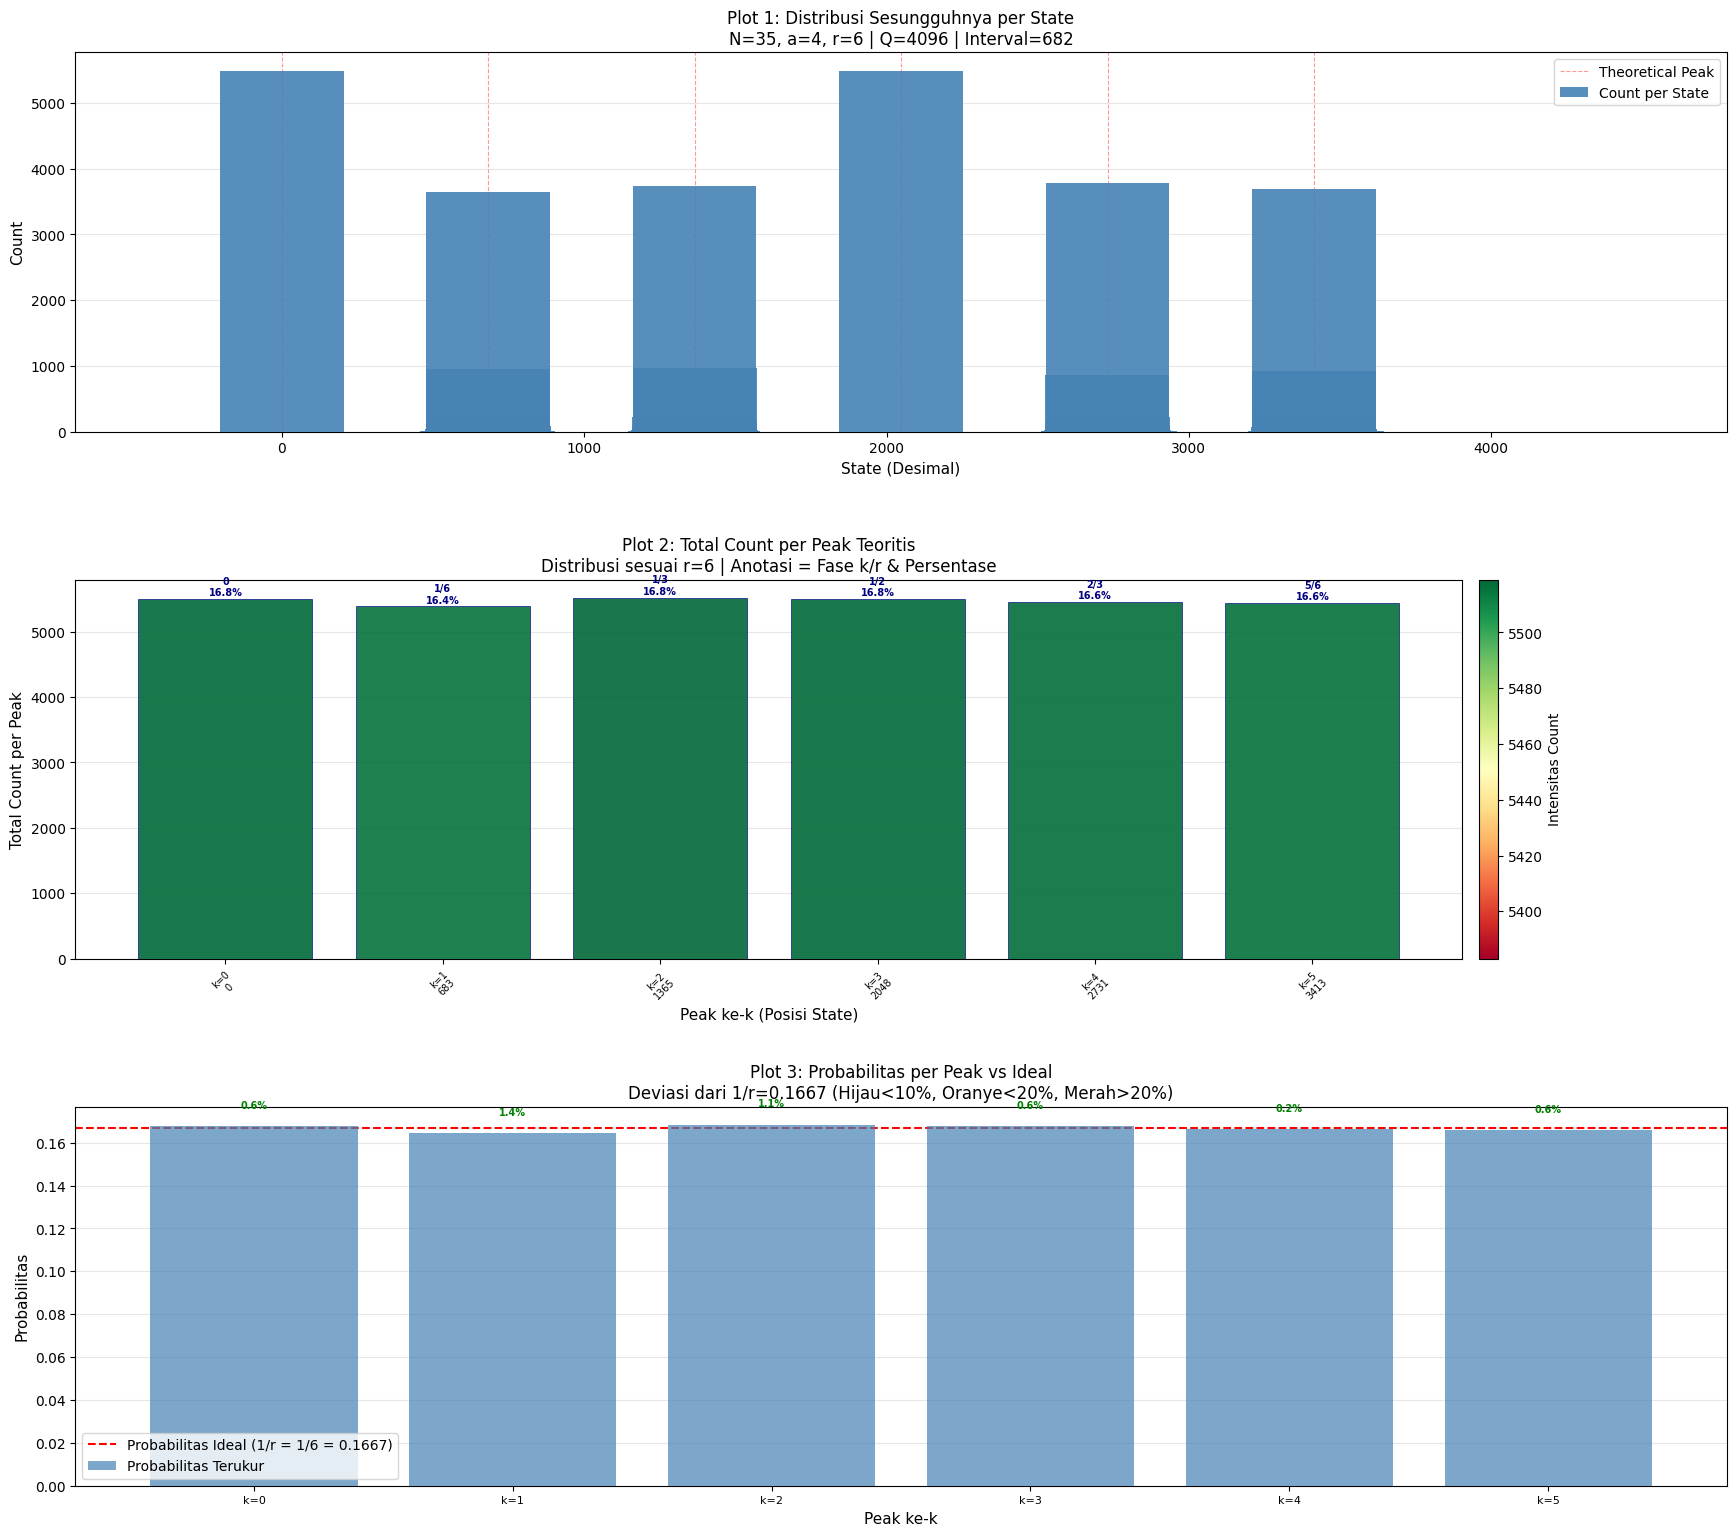


Statistik Distribusi N=35, a=4, r=6
Q=4096 | Interval=682 | Total Shots=32768
   k     Peak     Fase   Fraksi    Count       %   Deviasi
-----------------------------------------------------------------
   0        0   0.0000        0     5493  16.76%    0.10% ✅
   1      683   0.1667      1/6     5383  16.43%    0.24% ✅
   2     1365   0.3333      1/3     5519  16.84%    0.18% ✅
   3     2048   0.5000      1/2     5494  16.77%    0.10% ✅
   4     2731   0.6667      2/3     5449  16.63%    0.04% ✅
   5     3413   0.8333      5/6     5430  16.57%    0.10% ✅
Probabilitas ideal per peak : 16.67%
Std deviasi antar peak      : 0.14%


In [16]:
plot_periodic_histogram(counts, n_count, N, a, r)

In [17]:
def plot_periodic_histogram_2(counts, n_count, N, a, r):
    
    # Konversi semua state ke desimal
    decimal_counts = {}
    for state, count in counts.items():
        state_clean = state.replace(" ", "")[:n_count]
        dec = int(state_clean, 2)
        decimal_counts[dec] = decimal_counts.get(dec, 0) + count
    
    total_shots = sum(decimal_counts.values())
    Q           = 2 ** n_count
    theoretical_peaks = [round(k * Q / r) for k in range(r + 1) 
                         if round(k * Q / r) <= Q]

    # Pisahkan peak dan noise
    peak_counts  = {}
    noise_counts = {}
    for dec, count in decimal_counts.items():
        is_peak = any(abs(dec - p) <= Q // (r * 2) for p in theoretical_peaks)
        if is_peak:
            peak_counts[dec]  = count
        else:
            noise_counts[dec] = count

    fig, axes = plt.subplots(2, 1, figsize=(16, 12))

    # ══════════════════════════════════════════
    # Plot 1 — Histogram Penuh (Fix Visualisasi)
    # ══════════════════════════════════════════
    ax1    = axes[0]
    x_vals = sorted(decimal_counts.keys())
    y_vals = [decimal_counts[x] for x in x_vals]

    # Garis merah DULU (di belakang)
    for i, peak in enumerate(theoretical_peaks):
        ax1.axvline(x=peak, color='red', linestyle='--',
                    alpha=0.4,        # ← Transparan
                    linewidth=0.8,    # ← Tipis
                    zorder=1,         # ← Di belakang bar
                    label='Theoretical Peak' if i == 0 else "")

    # Bar SETELAH garis (di depan)
    bar_width = max(Q // (r * 4), 10)  # Proporsional, minimal 10
    ax1.bar(x_vals, y_vals,
            color='steelblue',
            alpha=0.9,
            width=bar_width,   # ← Lebih sempit & proporsional
            zorder=3,          # ← Di depan garis merah
            label='Counts')

    ax1.set_xlabel("State (Desimal)", fontsize=11)
    ax1.set_ylabel("Count", fontsize=11)
    ax1.set_title(f"Histogram Penuh — N={N}, a={a}, r={r}\n"
                  f"Peak Teoritis tiap {Q//r} state", fontsize=12)
    ax1.legend(fontsize=10)
    ax1.grid(axis='y', alpha=0.3)

    # ══════════════════════════════════════════
    # Plot 2 — Top 30 States dengan Anotasi Fase
    # ══════════════════════════════════════════
    ax2       = axes[1]
    top_items = sorted(decimal_counts.items(),
                       key=lambda x: x[1], reverse=True)[:30]
    top_x     = [item[0] for item in top_items]
    top_y     = [item[1] for item in top_items]

    # Warnai merah jika peak, biru jika noise
    colors = []
    for x in top_x:
        is_peak = any(abs(x - p) <= Q // (r * 2) for p in theoretical_peaks)
        colors.append('tomato' if is_peak else 'steelblue')

    ax2.bar(range(len(top_x)), top_y, color=colors, alpha=0.85, zorder=3)

    # Anotasi fase k/r
    for i, (x, y) in enumerate(zip(top_x, top_y)):
        phase = x / Q
        frac  = Fraction(phase).limit_denominator(N)
        ax2.text(i, y + max(top_y) * 0.01, f'{frac}',
                 fontsize=7, ha='center', color='navy', fontweight='bold')

    ax2.set_xticks(range(len(top_x)))
    ax2.set_xticklabels([str(x) for x in top_x], rotation=45, fontsize=8)
    ax2.set_xlabel("State (Desimal)", fontsize=11)
    ax2.set_ylabel("Count", fontsize=11)
    ax2.set_title(f"Top 30 States — Merah = Peak Periodik "
                  f"(interval ~{Q//r})\nAnotasi = Fase k/r", fontsize=12)

    legend_elements = [
        Patch(facecolor='tomato',    label=f'Peak periodik (dekat k×{Q//r})'),
        Patch(facecolor='steelblue', label='State lainnya (noise)')
    ]
    ax2.legend(handles=legend_elements, fontsize=10)
    ax2.grid(axis='y', alpha=0.3)

    plt.tight_layout(pad=3.0)
    plt.savefig(f"shor_histogram_N{N}_a{a}.png", dpi=150, bbox_inches='tight')
    plt.show()

    # ══════════════════════════════════════════
    # Verifikasi Posisi Bar vs Theoretical Peak
    # ══════════════════════════════════════════
    print(f"\n{'='*55}")
    print(f"Periodicitas untuk N={N}, a={a}, r={r}")
    print(f"Q = 2^{n_count} = {Q}")
    print(f"Interval antar peak = Q/r = {Q}/{r} = {Q//r}")

    print(f"\n{'k':<5} {'Peak Teoritis':<18} {'Fase (k/r)':<15} {'Fraksi'}")
    print("-" * 55)
    for k in range(min(r, 8)):
        peak  = round(k * Q / r)
        phase = k / r
        frac  = Fraction(phase).limit_denominator(N)
        print(f"{k:<5} {peak:<18} {phase:<15.4f} {frac}")

    # Verifikasi selisih state vs peak
    print(f"\n{'State':>8} {'Count':>8} {'Peak Terdekat':>15} "
          f"{'Selisih':>8} {'Valid':>6}")
    print("-" * 55)
    top10 = sorted(decimal_counts.items(),
                   key=lambda x: x[1], reverse=True)[:10]
    for state, count in top10:
        nearest = min(theoretical_peaks, key=lambda p: abs(p - state))
        diff    = abs(state - nearest)
        status  = "✅" if diff <= Q//(r*2) else "❌"
        print(f"{state:>8} {count:>8} {nearest:>15} {diff:>8} {status:>6}")

    # Statistik noise
    total_peak  = sum(peak_counts.values())
    total_noise = sum(noise_counts.values())
    noise_pct   = (total_noise / total_shots * 100) if total_shots > 0 else 0

    print(f"\n{'='*55}")
    print(f"Total shots    : {total_shots}")
    print(f"Count di peak  : {total_peak}  ({100-noise_pct:.2f}%)")
    print(f"Count di noise : {total_noise} ({noise_pct:.2f}%)")
    print(f"Bar width      : {bar_width} (Q//{r*4})")
    print(f"{'='*55}")

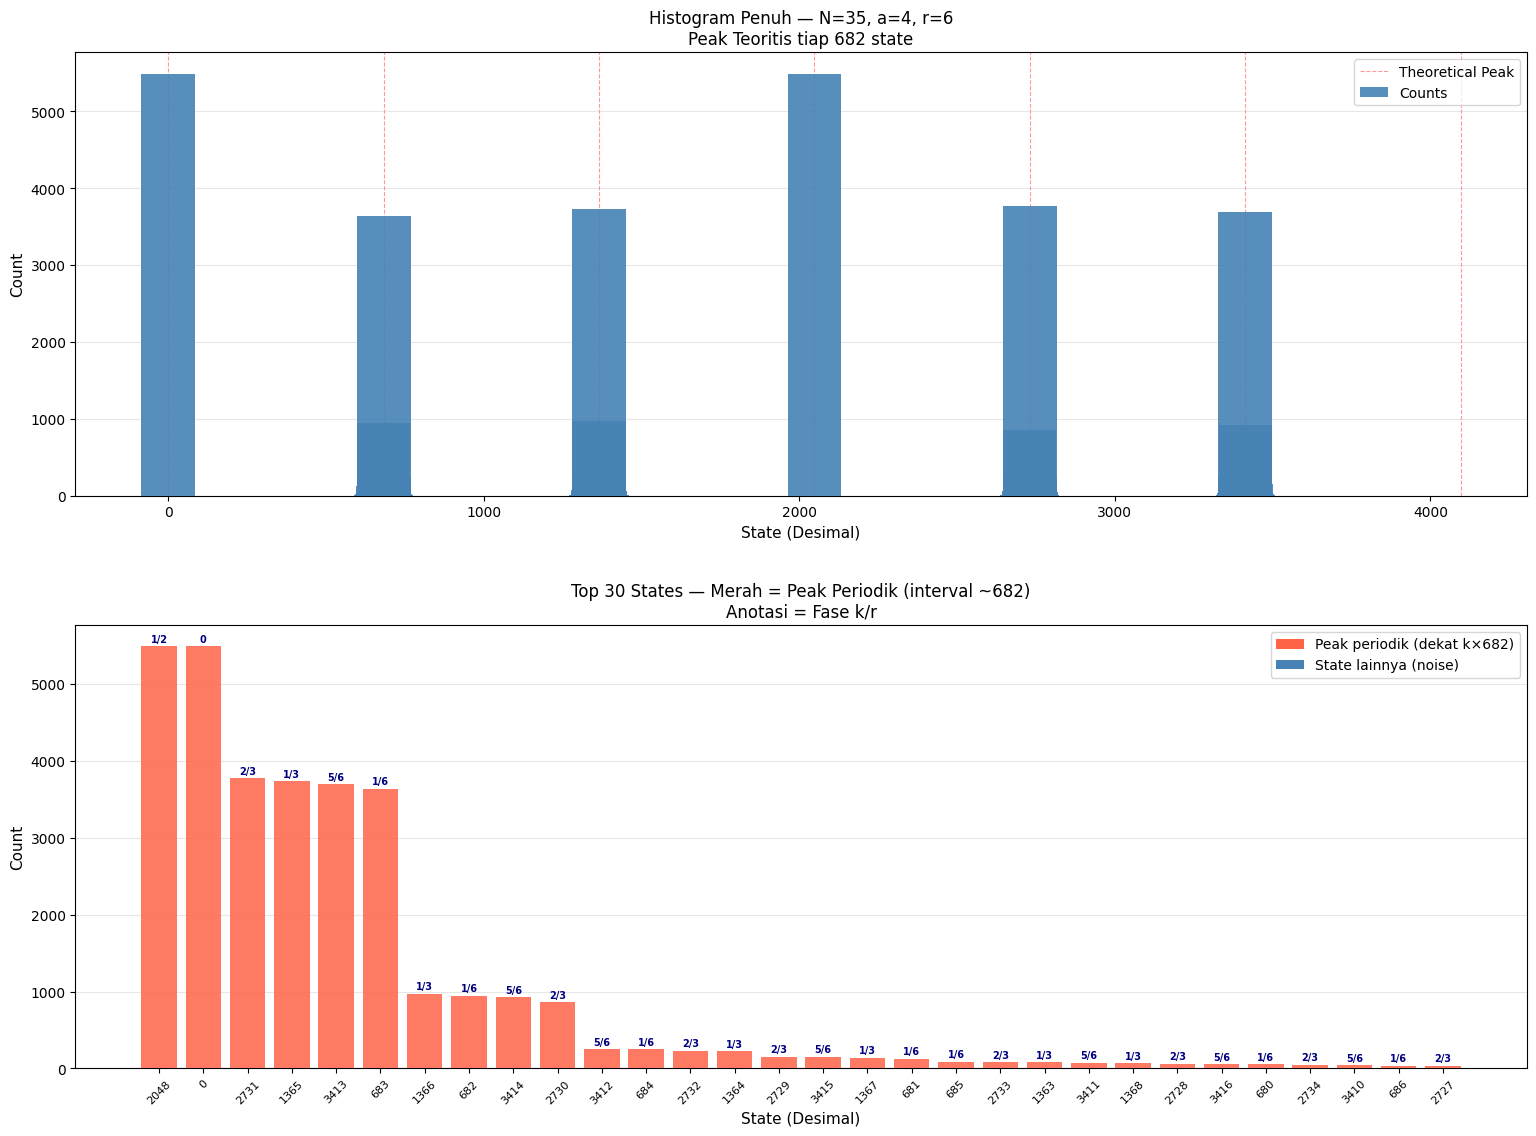


Periodicitas untuk N=35, a=4, r=6
Q = 2^12 = 4096
Interval antar peak = Q/r = 4096/6 = 682

k     Peak Teoritis      Fase (k/r)      Fraksi
-------------------------------------------------------
0     0                  0.0000          0
1     683                0.1667          1/6
2     1365               0.3333          1/3
3     2048               0.5000          1/2
4     2731               0.6667          2/3
5     3413               0.8333          5/6

   State    Count   Peak Terdekat  Selisih  Valid
-------------------------------------------------------
    2048     5493            2048        0      ✅
       0     5493               0        0      ✅
    2731     3775            2731        0      ✅
    1365     3737            1365        0      ✅
    3413     3697            3413        0      ✅
     683     3638             683        0      ✅
    1366      969            1365        1      ✅
     682      948             683        1      ✅
    3414      924           

In [18]:
plot_periodic_histogram_2(counts, n_count, N, a, r)

In [19]:
import socket
print(socket.gethostname())


trembesi02


In [1]:
import sys
print(sys.executable)
print(sys.version)

/mgpfs/home/mkhairiansyah/.conda/envs/env-ml/bin/python
3.10.19 (main, Oct 21 2025, 16:43:05) [GCC 11.2.0]
